# BONUS: Power BI Live Direct Query Demo

Demonstrates real-time reporting on a Delta table using Power BI in **Direct Query** mode with **Auto Page Refresh**. A streaming generator writes 1 row/second to the `live_orders` Gold table — Power BI reflects the data live without manual refresh.

> **BONUS MODULE** — Requires Power BI Desktop and an active SQL Warehouse.

## Learning Objectives

After completing this module you will be able to:

- **Start** a Structured Streaming job using the `rate` source to simulate live data
- **Connect** Power BI Desktop to Databricks via the certified connector
- **Configure** Direct Query mode and Auto Page Refresh in Power BI
- **Stop** a streaming query cleanly after the demo



## Setup

In [ ]:
%run ../setup/00_setup

## 5. Power BI — Live Direct Query Demo

**Goal:** generate a Delta table that receives 1 new row every second, then connect Power BI in **Direct Query** mode with **auto page-refresh** — the report updates automatically without pressing Refresh.

![alt text](../../assets/images/495258d03c654f39843544075e009eeb.webp)

### What we'll build

| Step | What | Tool |
|---|---|---|
| 1 | Create target Delta table | PySpark |
| 2 | Start streaming generator (1 row/s) | Structured Streaming |
| 3 | Verify data is flowing | Spark SQL |
| 4 | Connect Power BI — Direct Query + auto-refresh | Power BI Desktop |
| 5 | Stop the stream | PySpark |
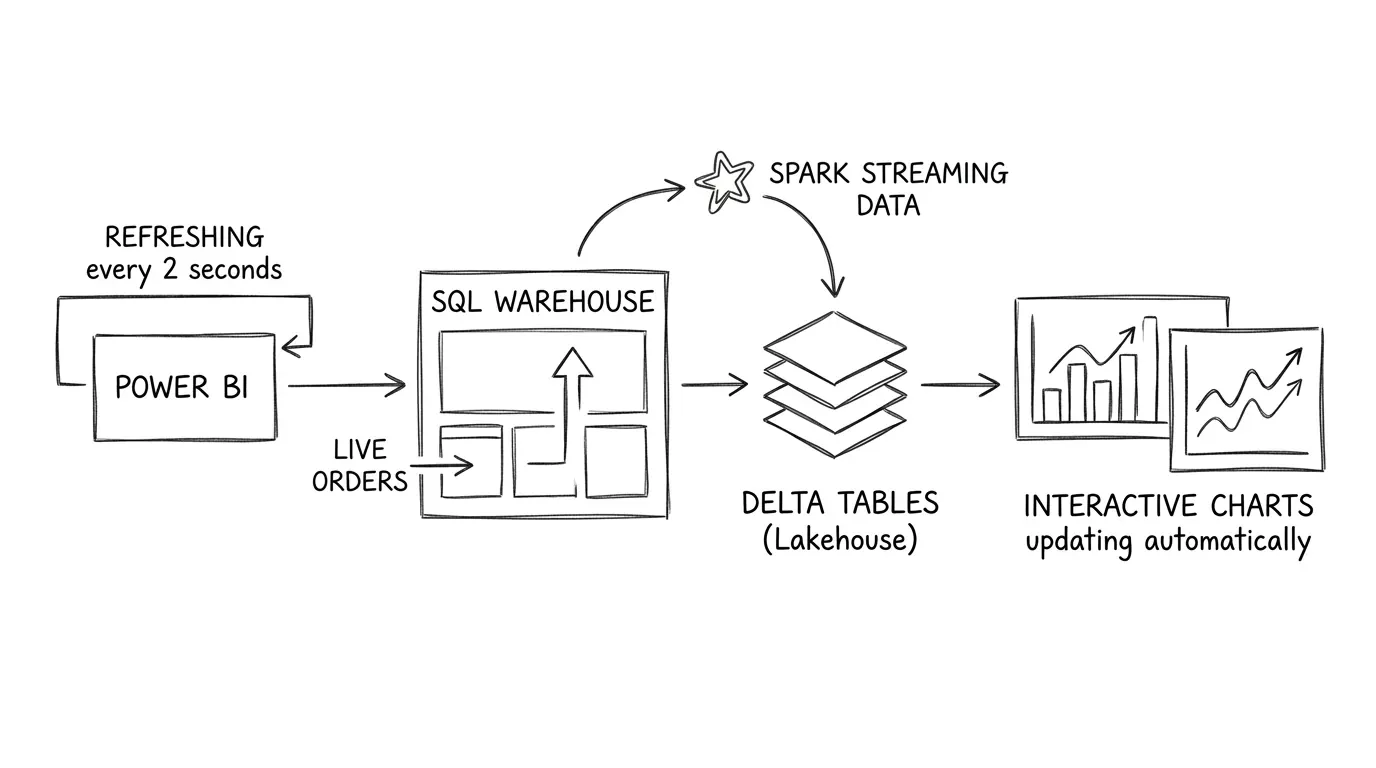

### Step 1 — Create the target Delta table

In [0]:
# Create (or recreate) the live_orders table in the Gold schema
spark.sql(f"""
    CREATE OR REPLACE TABLE  {CATALOG}.{GOLD_SCHEMA}.live_orders (
        event_time   TIMESTAMP,
        order_id     BIGINT,
        customer_id  INT,
        category     STRING,
        order_amount DECIMAL(10,2),
        store_region STRING
    )
    USING DELTA
""")

spark.sql(f"TRUNCATE TABLE {CATALOG}.{GOLD_SCHEMA}.live_orders")
print(f"Table ready: {CATALOG}.{GOLD_SCHEMA}.live_orders")

### Step 2 — Start the streaming generator (1 row / second)

Uses Spark **Structured Streaming** with the built-in `rate` source — no external data needed.
Each micro-batch appends exactly 1 row to the Delta table.

In [0]:
from pyspark.sql import functions as F

CATEGORIES   = ["Electronics", "Clothing", "Food", "Books", "Sports"]
REGIONS      = ["North", "South", "East", "West", "Central"]

# ── rate source: emits (timestamp, value) at 1 row/second ──
raw_stream = (
    spark.readStream
        .format("rate")
        .option("rowsPerSecond", 1)
        .load()
)

# ── enrich with business fields ──
live_stream = raw_stream.select(
    F.col("timestamp").alias("event_time"),
    F.col("value").alias("order_id"),
    (F.col("value") % 50 + 1).cast("int").alias("customer_id"),
    F.element_at(
        F.array(*[F.lit(c) for c in CATEGORIES]),
        (F.col("value") % len(CATEGORIES) + 1).cast("int")
    ).alias("category"),
    (F.rand() * 490 + 10).cast("decimal(10,2)").alias("order_amount"),
    F.element_at(
        F.array(*[F.lit(r) for r in REGIONS]),
        (F.col("value") % len(REGIONS) + 1).cast("int")
    ).alias("store_region"),
)

# ── write to Delta table ──
live_query = (
    live_stream.writeStream
        .format("delta")
        .outputMode("append")
        .option("checkpointLocation", f"/tmp/checkpoints/live_orders_{CATALOG}")
        .toTable(f"{CATALOG}.{GOLD_SCHEMA}.live_orders")
)

print(f"Stream running — writing 1 row/s to {CATALOG}.{GOLD_SCHEMA}.live_orders")
print(f"Stream ID: {live_query.id}")

### Step 3 — Verify data is flowing

Run this cell a few times — the row count should increase by ~1 each second.

In [0]:
import time
time.sleep(5)   # wait for a few rows to land

spark.sql(f"""
    SELECT
        COUNT(*)                   AS total_rows,
        MAX(event_time)            AS latest_event,
        ROUND(SUM(order_amount),2) AS total_revenue
    FROM {CATALOG}.{GOLD_SCHEMA}.live_orders
""").display()

print("--- latest 5 rows ---")
spark.sql(f"""
    SELECT *
    FROM   {CATALOG}.{GOLD_SCHEMA}.live_orders
    ORDER BY event_time DESC
    LIMIT 5
""").display()

### Step 4 — Connect Power BI (Direct Query + Auto Page Refresh)

#### 4a — Get SQL Warehouse connection details

1. Open **SQL Warehouses** in the Databricks sidebar
2. Click your warehouse → **Connection details** tab
3. Copy **Server hostname** and **HTTP Path**

#### 4b — Connect Power BI Desktop

1. **Get Data** → search for **Databricks** → select the certified connector
2. Paste **Server hostname** and **HTTP Path** → click **OK**
3. Authentication: choose **Personal Access Token** (PAT) → paste your token
4. In the Navigator, expand your catalog: `{CATALOG}` → `gold` → tick **live_orders** → **Load**
5. In the **Connection Settings** dialog choose **DirectQuery** → click **OK**

> **DirectQuery** means every chart refresh sends a live SQL query to the SQL Warehouse — no data is cached in Power BI.

#### 4c — Build a simple live chart

1. Insert a **Card** visual → drag `total_rows = COUNT(order_id)` into it
2. Insert a **Bar Chart** → X-axis: `category`, Y-axis: `SUM(order_amount)`
3. Insert a **Table** visual → columns: `event_time`, `customer_id`, `category`, `order_amount`

#### 4d — Enable Auto Page Refresh

> Requires **Power BI Desktop** ≥ March 2020 and a workspace on **Premium / Fabric capacity** for intervals below 30 min. For demo purposes use a local Power BI Desktop connected to a SQL Warehouse.

1. Click anywhere on the **canvas** (deselect all visuals)
2. In the **Visualizations** pane open **Page** settings (canvas icon)
3. Scroll to **Page refresh** → toggle **On**
4. Set interval: **2 seconds** (minimum allowed depends on capacity)
5. Save and publish — the page will re-query the SQL Warehouse every 2 s

![alt text](../../assets/images/495258d03c654f39843544075e009eeb.webp)

| Setting | Value for demo |
|---|---|
| Connection mode | DirectQuery |
| Auto page refresh interval | 2 seconds |
| Refresh trigger | Fixed interval |
| SQL Warehouse auto-stop | Disable during demo (or set 30 min) |


### Step 5 — Stop the stream (cleanup)

In [0]:
# Run this cell after the demo to stop the streaming query
live_query.stop()
print("Stream stopped.")
print(f"Final row count: {spark.table(f'{CATALOG}.{GOLD_SCHEMA}.live_orders').count()}")

## Summary

| Step | What | Tool |
|---|---|---|
| 1 | Create `live_orders` Delta table (Gold schema) | `CREATE OR REPLACE TABLE` |
| 2 | Start streaming generator (rate source, 1 row/s) | Structured Streaming |
| 3 | Verify data is flowing | `spark.sql()` |
| 4 | Connect Power BI — Direct Query + Auto Page Refresh | Power BI Desktop |
| 5 | Stop stream after demo | `query.stop()` |

> **Key concepts:** `rate` source, Structured Streaming, Direct Query, Auto Page Refresh



**[ README](../../README.md)**